# **Exploratory Data Analysis (EDA)**

## Purpose

This notebook explores the cleaned Consumer Complaint dataset to identify:

- complaint volume and distribution patterns,
- the most common products and issues,
- complaint trends over time,
- differences in timely response rates,
- relationships between complaint characteristics and timely response,
- response-time patterns,
- potential insights relevant to later modeling.

**Data source:** `complaints_cleaned.parquet`

**Scope:** This notebook focuses on exploration and interpretation. Data cleaning decisions belong to `02_Data_Cleaning.ipynb`, and predictive modeling should be performed in a later notebook.

## EDA Roadmap

1. Environment and data loading  
2. Dataset overview and quality context  
3. Complaint volume by product  
4. Complaint issues and product-specific issues  
5. Complaint trends over time  
6. Target distribution: timely response  
7. Timely response by product and submission method  
8. Company response analysis and target-leakage note  
9. Timely response by state, issue, company, and sub-product  
10. Complaint forwarding time  
11. Complaint tags and narrative availability  
12. Missing-value context for later modeling  
13. EDA findings and modeling handoff

# **1. Environment Setup**

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **2. Load the Cleaned DataSet**

In [3]:
file_path = "/content/drive/MyDrive/Consumer Complain Project/data/processed/complaints_cleaned.parquet"

df = pd.read_parquet(file_path)

print("Cleaned dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset loaded successfully.
Rows: 90112
Columns: 16


# **3. Dataset Overview and Quality Context**

This section confirms the structure of the cleaned dataset and provides context about remaining missing values. Missing values retained after cleaning are not necessarily errors; several fields were intentionally left missing because their values cannot be safely inferred.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90112 entries, 0 to 90111
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   date_received                 90112 non-null  datetime64[us, UTC]
 1   product                       90112 non-null  object             
 2   sub_product                   90112 non-null  object             
 3   issue                         90112 non-null  object             
 4   sub_issue                     90112 non-null  object             
 5   consumer_complaint_narrative  20112 non-null  object             
 6   company_public_response       35420 non-null  object             
 7   company                       90112 non-null  object             
 8   state                         90112 non-null  object             
 9   zip_code                      90112 non-null  string             
 10  tags                          9011

In [5]:
print("Missing Values in Cleaned Dataset")
print("---------------------------------")

missing_values = df.isna().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": (missing_values / len(df) * 100).round(2)
})

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ].sort_values("missing_count", ascending=False)
)

Missing Values in Cleaned Dataset
---------------------------------


,missing_count,missing_percentage
consumer_complaint_narrative,70000,77.68
company_public_response,54692,60.69
company_response_to_consumer,15807,17.54
date_sent_to_company,3180,3.53


In [6]:
unique_summary = pd.DataFrame({
    "column": df.columns,
    "unique_values": [df[column].nunique(dropna=True) for column in df.columns]
}).sort_values("unique_values", ascending=False)

print("Unique Values by Column")
print("-----------------------")
display(unique_summary)

Unique Values by Column
-----------------------


,column,unique_values
15,complaint_id,90112
0,date_received,88993
12,date_sent_to_company,85806
5,consumer_complaint_narrative,18358
9,zip_code,10830
7,company,1499
4,sub_issue,207
3,issue,92
8,state,60
2,sub_product,58




## **4.   Which financial products generate the highest number of consumer complaints?**



In [7]:
product_counts = df["product"].value_counts()

print("Complaints by Product")
print("---------------------")
print(product_counts)

Complaints by Product
---------------------
product
Credit reporting or other personal consumer reports        63131
Debt collection                                             9700
Checking or savings account                                 4264
Credit card                                                 4220
Money transfer, virtual currency, or money service          2034
Mortgage                                                    1758
Vehicle loan or lease                                       1444
Payday loan, title loan, personal loan, or advance loan     1122
Student loan                                                1011
Prepaid card                                                 728
Debt or credit management                                    655
Other                                                         45
Name: count, dtype: int64


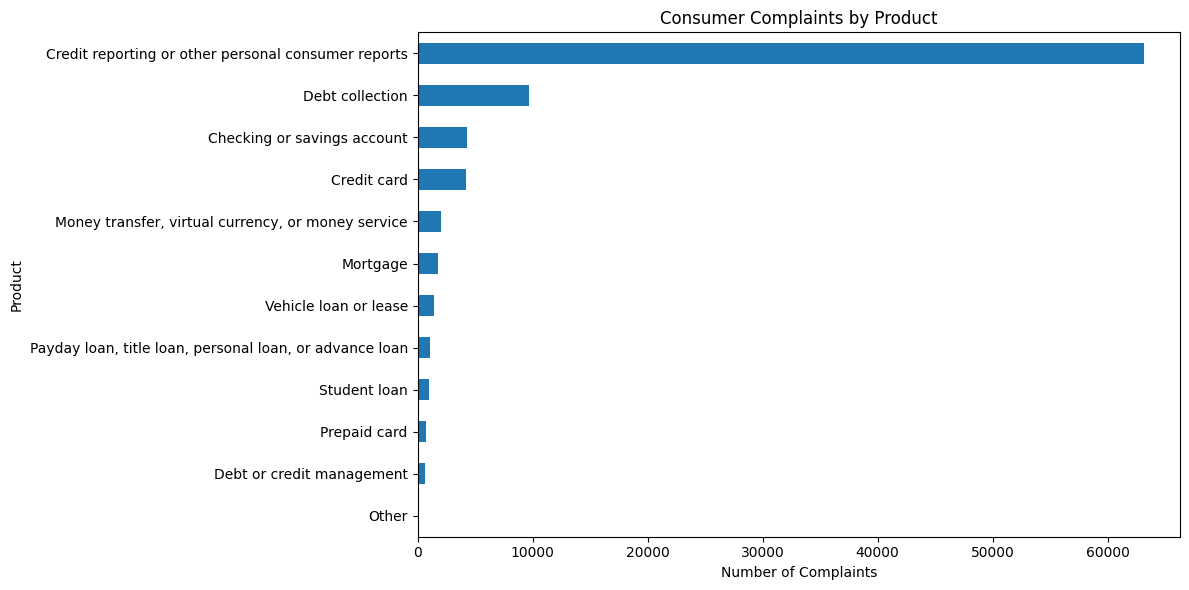

In [8]:
plt.figure(figsize=(12, 6))

product_counts.sort_values().plot(kind="barh")

plt.title("Consumer Complaints by Product")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")

plt.tight_layout()
plt.show()



# **5. What are the most common complaint issues?**



In [9]:
print("Complaints by Issue")
print("-------------------")

issue_counts = df["issue"].value_counts()

print(issue_counts)

Complaints by Issue
-------------------
issue
Incorrect information on your report                               37917
Improper use of your report                                        13369
Problem with a company's investigation into an existing problem    12256
Attempts to collect debt not owed                                   4734
Managing an account                                                 2340
                                                                   ...  
Problems when you are unable to pay                                    1
Disclosure verification of debt                                        1
Cont'd attempts collect debt not owed                                  1
Account opening, closing, or management                                1
Loan modification,collection,foreclosure                               1
Name: count, Length: 92, dtype: int64


In [10]:
top_10_issues = issue_counts.head(10).sort_values()

print("Top 10 Complaint Issues")
print("----------------------")

print(top_10_issues.sort_values(ascending=False))

Top 10 Complaint Issues
----------------------
issue
Incorrect information on your report                               37917
Improper use of your report                                        13369
Problem with a company's investigation into an existing problem    12256
Attempts to collect debt not owed                                   4734
Managing an account                                                 2340
Written notification about debt                                     1637
Took or threatened to take negative or legal action                 1509
Problem with a purchase shown on your statement                     1492
False statements or representation                                  1131
Trouble during payment process                                       877
Name: count, dtype: int64


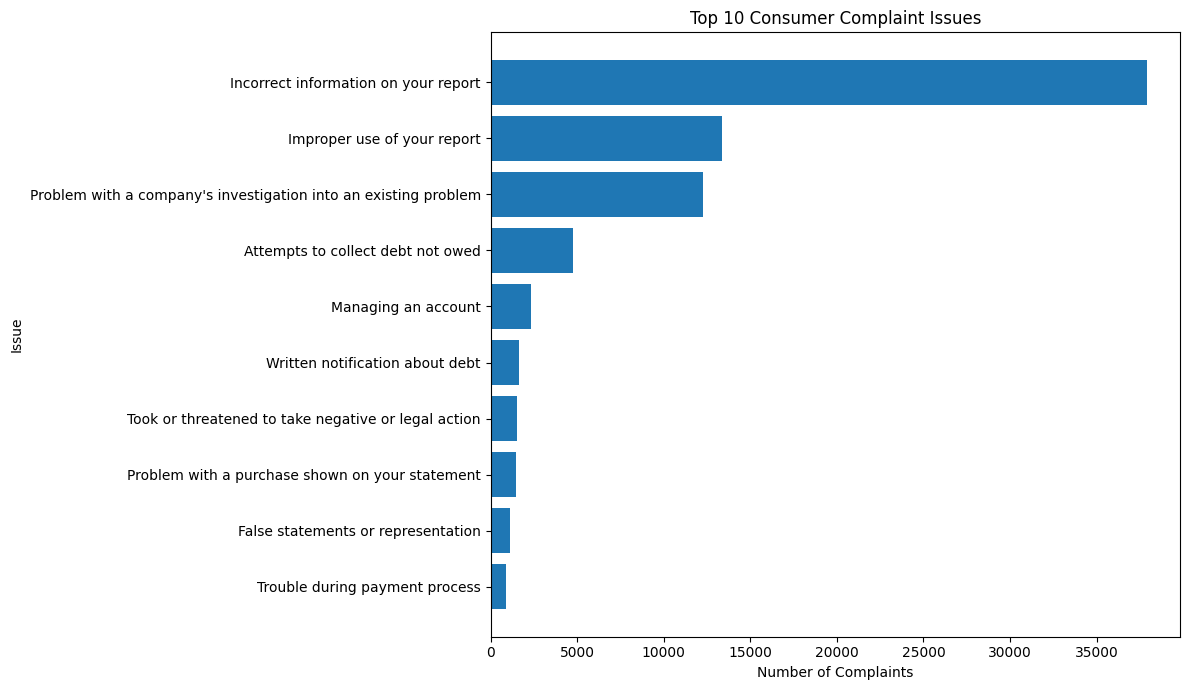

In [11]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_10_issues.index,
    top_10_issues.values
)

plt.title("Top 10 Consumer Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")

plt.tight_layout()
plt.show()

# **6. What problems do customers report most often for each major product?**

To keep the analysis readable, the five products with the highest complaint volumes are examined. For each of these products, the five most common issues are identified.

In [12]:
top_5_products = product_counts.head(5)

print("Top 5 Products")
print("---------------")

print(top_5_products)

Top 5 Products
---------------
product
Credit reporting or other personal consumer reports    63131
Debt collection                                         9700
Checking or savings account                             4264
Credit card                                             4220
Money transfer, virtual currency, or money service      2034
Name: count, dtype: int64


In [13]:
top_product_issue_data = []

for product in top_5_products.index:

    product_data = df[df["product"] == product]

    issue_counts_for_product = product_data["issue"].value_counts()

    top_5_issues = issue_counts_for_product.head(5)

    for issue, count in top_5_issues.items():
        top_product_issue_data.append({
            "product": product,
            "issue": issue,
            "complaint_count": count
        })

top_product_issue_df = pd.DataFrame(top_product_issue_data)

print("Top 5 Issues for Each of the Top 5 Products")
print("--------------------------------------")

print(top_product_issue_df)

Top 5 Issues for Each of the Top 5 Products
--------------------------------------
                                              product  \
0   Credit reporting or other personal consumer re...   
1   Credit reporting or other personal consumer re...   
2   Credit reporting or other personal consumer re...   
3   Credit reporting or other personal consumer re...   
4   Credit reporting or other personal consumer re...   
5                                     Debt collection   
6                                     Debt collection   
7                                     Debt collection   
8                                     Debt collection   
9                                     Debt collection   
10                        Checking or savings account   
11                        Checking or savings account   
12                        Checking or savings account   
13                        Checking or savings account   
14                        Checking or savings account   
15   

In [14]:
def plot_top_issues_for_product(product_name, value_padding):
    product_data = (
        top_product_issue_df[
            top_product_issue_df["product"] == product_name
        ]
        .sort_values("complaint_count")
    )

    plt.figure(figsize=(11, 6))

    bars = plt.barh(
        product_data["issue"],
        product_data["complaint_count"]
    )

    for bar in bars:
        value = bar.get_width()
        plt.text(
            value + value_padding,
            bar.get_y() + bar.get_height() / 2,
            f"{int(value):,}",
            va="center"
        )

    plt.xlim(
        0,
        product_data["complaint_count"].max() * 1.10
    )

    plt.title(f"Top 5 Problems Reported for {product_name}")
    plt.xlabel("Number of Complaints")
    plt.ylabel("Issue")
    plt.tight_layout()
    plt.show()

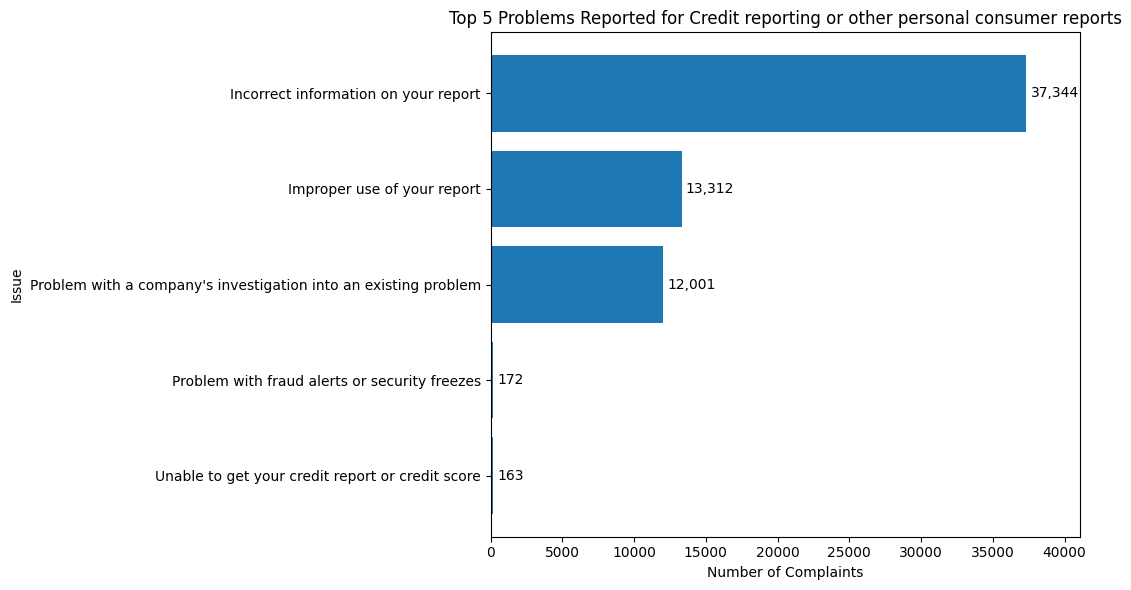

In [15]:
plot_top_issues_for_product(
    "Credit reporting or other personal consumer reports",
    300
)

In [16]:
credit_reporting_data = top_product_issue_df[
    top_product_issue_df["product"] == "Credit reporting or other personal consumer reports"
]

print(credit_reporting_data)

                                             product  \
0  Credit reporting or other personal consumer re...   
1  Credit reporting or other personal consumer re...   
2  Credit reporting or other personal consumer re...   
3  Credit reporting or other personal consumer re...   
4  Credit reporting or other personal consumer re...   

                                               issue  complaint_count  
0               Incorrect information on your report            37344  
1                        Improper use of your report            13312  
2  Problem with a company's investigation into an...            12001  
3      Problem with fraud alerts or security freezes              172  
4   Unable to get your credit report or credit score              163  


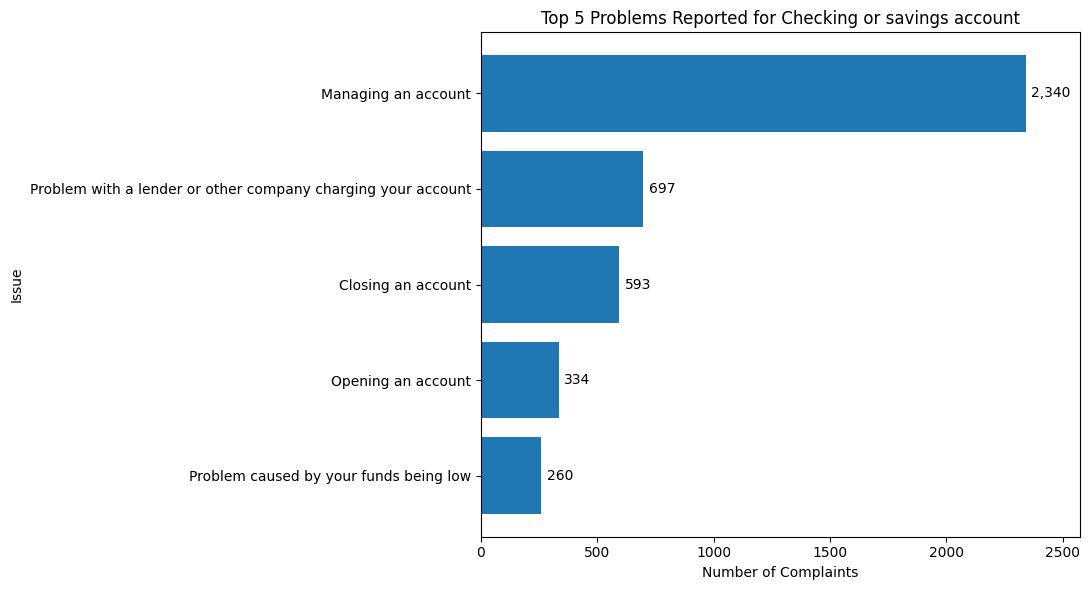

In [17]:
plot_top_issues_for_product(
    "Checking or savings account",
    25
)

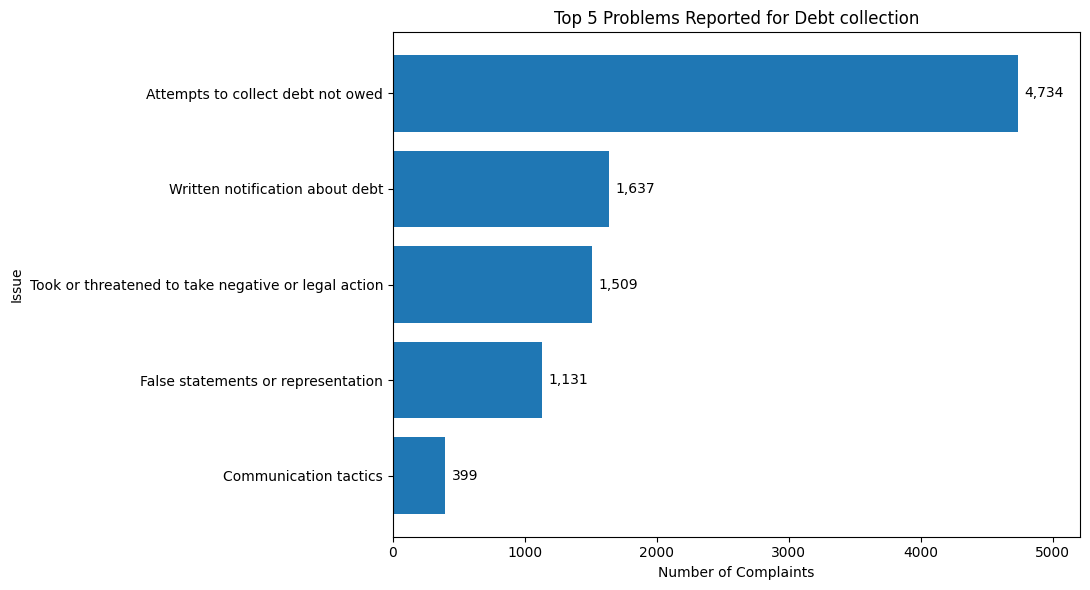

In [18]:
plot_top_issues_for_product(
    "Debt collection",
    50
)

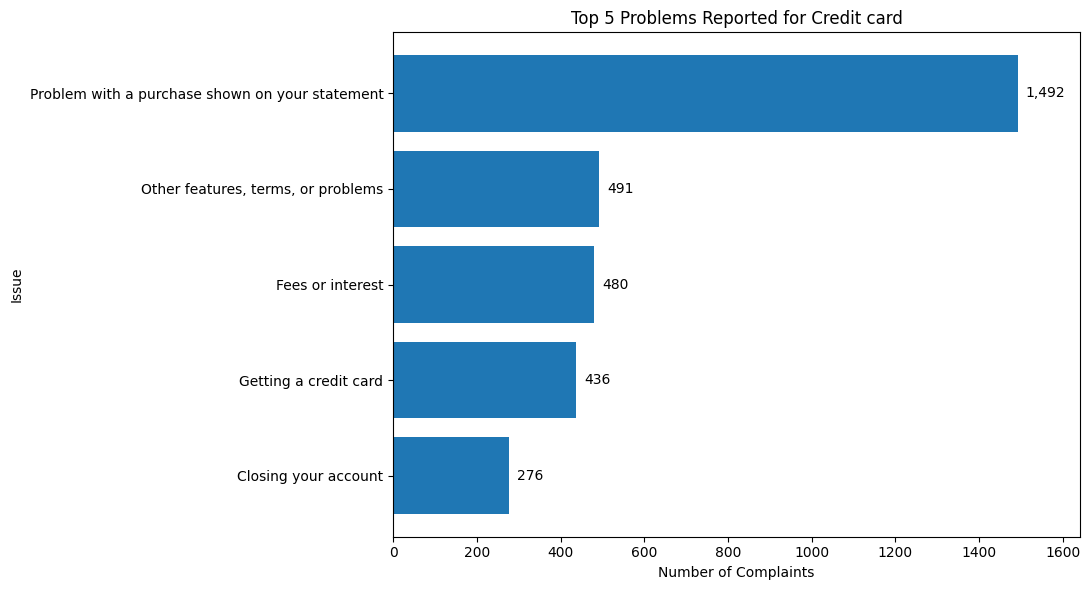

In [19]:
plot_top_issues_for_product(
    "Credit card",
    20
)

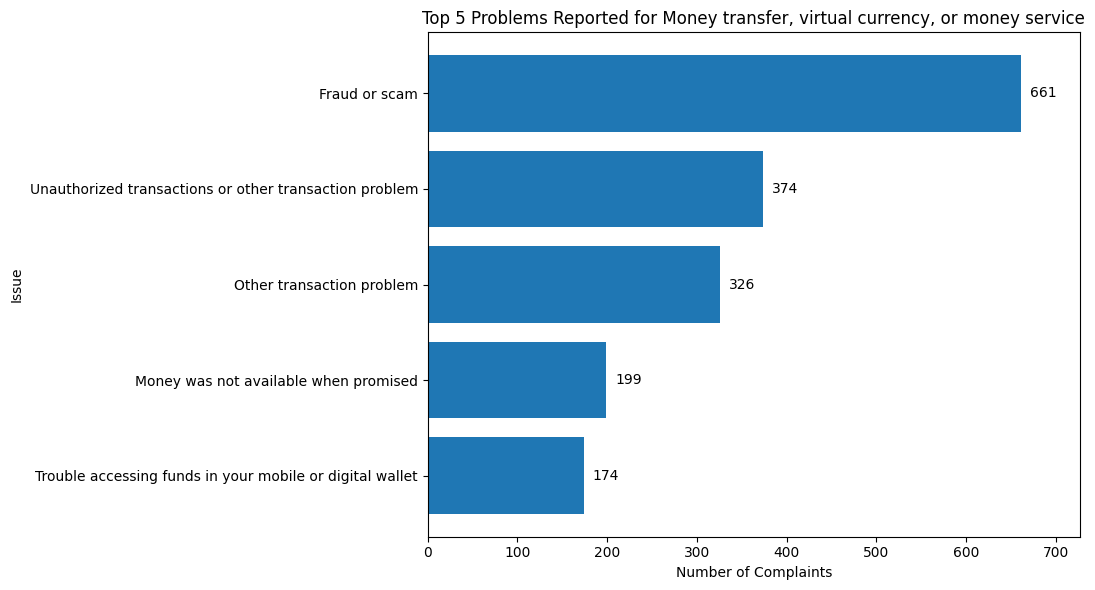

In [20]:
plot_top_issues_for_product(
    "Money transfer, virtual currency, or money service",
    10
)

# **7. How Does the Number of Complaints Change Over Time?**

In [21]:
print("Complaint Date Range")
print("--------------------")

print("Start date:", df["date_received"].min())
print("End date:", df["date_received"].max())

Complaint Date Range
--------------------
Start date: 2014-07-24 00:33:39+00:00
End date: 2026-07-06 09:05:16+00:00


In [22]:
monthly_complaints = (
    df.set_index("date_received")
      .resample("ME")
      .size()
)

non_zero_months = monthly_complaints[monthly_complaints > 0]

print("First month with complaints:", non_zero_months.index.min())
print("Last month with complaints:", non_zero_months.index.max())
print("Number of months with complaints:", len(non_zero_months))

First month with complaints: 2014-07-31 00:00:00+00:00
Last month with complaints: 2026-07-31 00:00:00+00:00
Number of months with complaints: 58


In [23]:
yearly_complaints = (
    df.set_index("date_received")
      .resample("YE")
      .size()
)

print("Complaints by Year")
print("------------------")
print(yearly_complaints[yearly_complaints > 0])

Complaints by Year
------------------
date_received
2014-12-31 00:00:00+00:00        1
2016-12-31 00:00:00+00:00        4
2017-12-31 00:00:00+00:00        4
2018-12-31 00:00:00+00:00        5
2019-12-31 00:00:00+00:00        3
2020-12-31 00:00:00+00:00        4
2021-12-31 00:00:00+00:00        2
2022-12-31 00:00:00+00:00        6
2023-12-31 00:00:00+00:00       45
2024-12-31 00:00:00+00:00       23
2025-12-31 00:00:00+00:00      447
2026-12-31 00:00:00+00:00    89568
dtype: int64


In [24]:
complaints_2026 = (
    df[df["date_received"].dt.year == 2026]
    .set_index("date_received")
    .resample("ME")
    .size()
)

print("Monthly Complaints in 2026")
print("--------------------------")
print(complaints_2026)

Monthly Complaints in 2026
--------------------------
date_received
2026-01-31 00:00:00+00:00      374
2026-02-28 00:00:00+00:00     4630
2026-03-31 00:00:00+00:00    11485
2026-04-30 00:00:00+00:00    20979
2026-05-31 00:00:00+00:00    18469
2026-06-30 00:00:00+00:00    24974
2026-07-31 00:00:00+00:00     8657
Freq: ME, dtype: int64


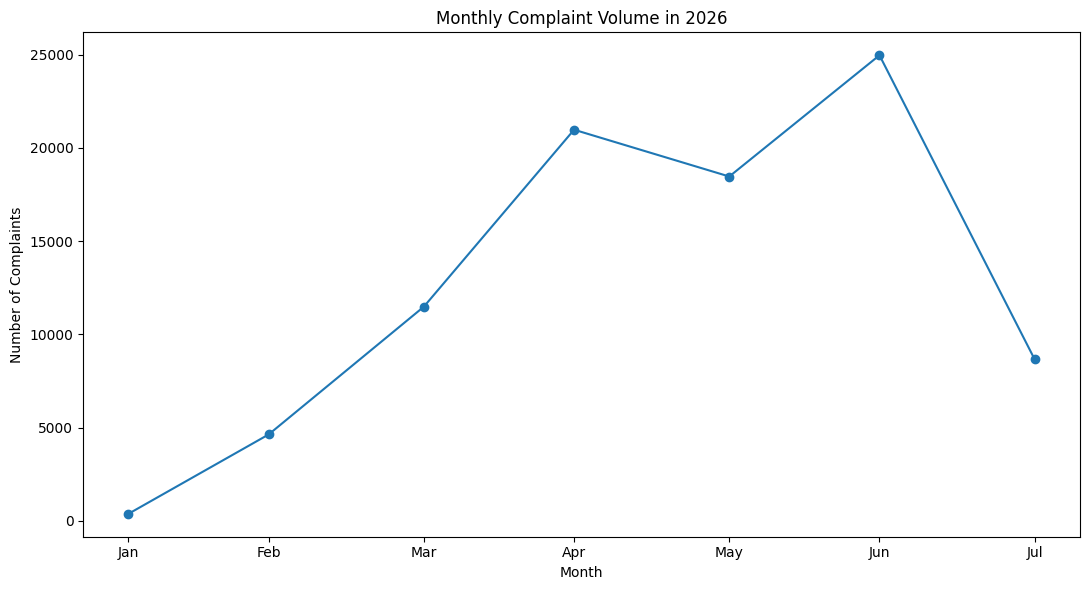

In [25]:
plt.figure(figsize=(11, 6))

plt.plot(
    complaints_2026.index,
    complaints_2026.values,
    marker="o"
)

plt.title("Monthly Complaint Volume in 2026")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")

plt.xticks(
    complaints_2026.index,
    complaints_2026.index.strftime("%b")
)

plt.tight_layout()
plt.show()

**Note:** The dataset ends on July 6, 2026. Therefore, July 2026 is partial-month data and should not be directly compared with complete months.

# **8. Timely Response Distribution**

`timely_response` is the outcome of interest for the later predictive-modeling stage. Its distribution is examined first to understand potential class imbalance.

In [26]:
timely_response_counts = df["timely_response"].value_counts()

print("Timely Response Distribution")
print("----------------------------")
print(timely_response_counts)

print("Target Percentage")
print("-----------------")
print(
    (df["timely_response"]
       .value_counts(normalize=True) * 100)
    .round(2)
)

Timely Response Distribution
----------------------------
timely_response
Yes    89009
No      1103
Name: count, dtype: int64
Target Percentage
-----------------
timely_response
Yes    98.78
No      1.22
Name: proportion, dtype: float64


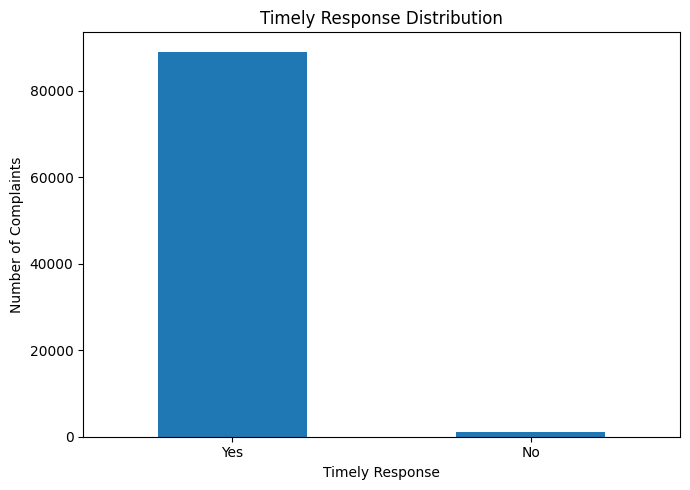

In [27]:
plt.figure(figsize=(7, 5))

timely_response_counts.plot(kind="bar")

plt.title("Timely Response Distribution")
plt.xlabel("Timely Response")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The target distribution is highly imbalanced, with timely responses representing the large majority of complaints. This should be considered during later modeling and model evaluation.

# **9. Does Timely Response Differ Across Financial Products?**

In [28]:
timely_response_by_product = (
    pd.crosstab(
        df["product"],
        df["timely_response"],
        normalize="index"
    ) * 100
).round(2)

print("Timely Response Rate by Product")
print("--------------------------------")
print(timely_response_by_product)

Timely Response Rate by Product
--------------------------------
timely_response                                        No     Yes
product                                                          
Checking or savings account                          1.38   98.62
Credit card                                          1.49   98.51
Credit reporting or other personal consumer rep...   0.13   99.87
Debt collection                                      3.27   96.73
Debt or credit management                            5.50   94.50
Money transfer, virtual currency, or money service   4.38   95.62
Mortgage                                             2.16   97.84
Other                                                0.00  100.00
Payday loan, title loan, personal loan, or adva...   5.44   94.56
Prepaid card                                         5.22   94.78
Student loan                                        28.19   71.81
Vehicle loan or lease                                2.29   97.71


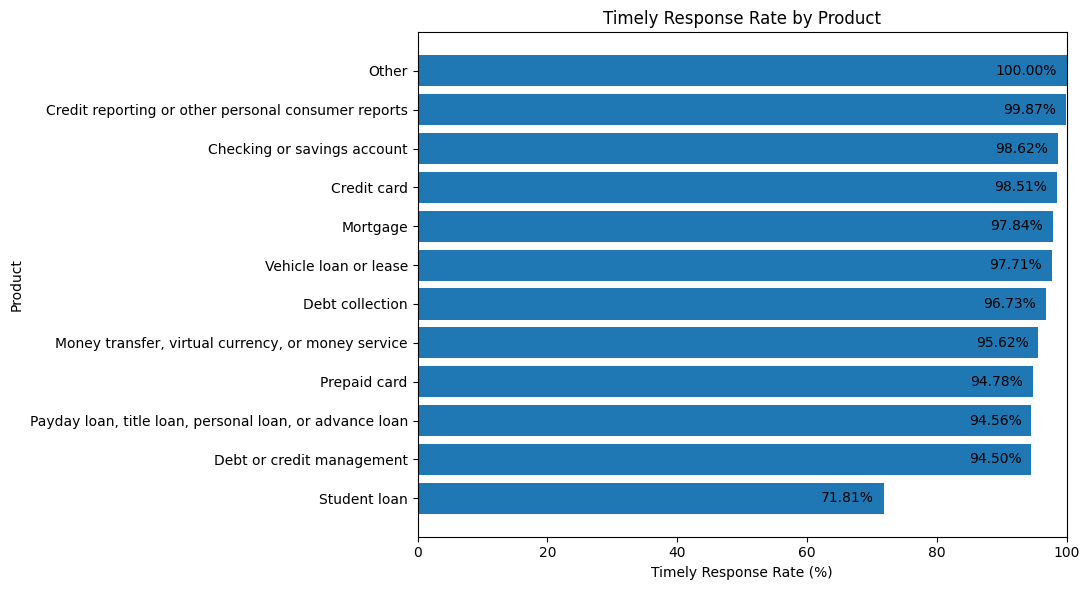

In [29]:
timely_response_yes = (
    timely_response_by_product["Yes"]
    .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    timely_response_yes.index,
    timely_response_yes.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value - 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

plt.xlim(0, 100)
plt.title("Timely Response Rate by Product")
plt.xlabel("Timely Response Rate (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# **10. Does Timely Response Differ by Submission Method?**

In [30]:
timely_response_by_submission = (
    pd.crosstab(
        df["submitted_via"],
        df["timely_response"],
        normalize="index"
    ) * 100
).round(2)

print("Timely Response Rate by Submission Method")
print("------------------------------------------")
print(timely_response_by_submission)

Timely Response Rate by Submission Method
------------------------------------------
timely_response    No     Yes
submitted_via                
Phone            2.69   97.31
Postal mail      0.00  100.00
Referral         0.57   99.43
Web              1.22   98.78


In [31]:
submission_counts = df["submitted_via"].value_counts()

print("Complaints by Submission Method")
print("-------------------------------")
print(submission_counts)

Complaints by Submission Method
-------------------------------
submitted_via
Web            89427
Phone            334
Postal mail      176
Referral         175
Name: count, dtype: int64


**Interpretation:** Timely response rates are high across all submission methods, while Phone has the lowest rate in this dataset. Most complaints were submitted through the Web, so the other submission methods have much smaller sample sizes.

# **11. Does Timely Response Change by Company Response?**

This relationship is explored descriptively, but the variable also requires a leakage check before modeling.

In [32]:
company_response_counts = df["company_response_to_consumer"].value_counts(dropna=False)

print("Company Response to Consumer")
print("----------------------------")
print(company_response_counts)

Company Response to Consumer
----------------------------
company_response_to_consumer
Closed with explanation            50849
None                               15807
Closed with non-monetary relief    11897
In progress                         9467
Closed with monetary relief         1576
Untimely response                    516
Name: count, dtype: int64


In [33]:
response_by_timely = (
    pd.crosstab(
        df.loc[
            df["company_response_to_consumer"].notna(),
            "company_response_to_consumer"
        ],
        df.loc[
            df["company_response_to_consumer"].notna(),
            "timely_response"
        ],
        normalize="index"
    ) * 100
).round(2)

print("Company Response by Timely Response")
print("-----------------------------------")
print(response_by_timely)

Company Response by Timely Response
-----------------------------------
timely_response                      No     Yes
company_response_to_consumer                   
Closed with explanation            1.08   98.92
Closed with monetary relief        1.97   98.03
Closed with non-monetary relief    0.08   99.92
In progress                        0.00  100.00
Untimely response                100.00    0.00


**Modeling note — potential target leakage:** `company_response_to_consumer` should not be used automatically as a predictor for `timely_response`. The category `Untimely response` directly corresponds to `timely_response = No`, so the variable may contain information about the target itself. This would create target leakage in a predictive model.

# **12. Does Timely Response Differ by State?**

In [34]:
state_counts = df["state"].value_counts()

print("Complaints by State")
print("-------------------")
print(state_counts)

Complaints by State
-------------------
state
TX                                      14161
FL                                      12160
CA                                       8734
GA                                       6212
NY                                       4534
IL                                       3658
NC                                       3160
PA                                       2935
NJ                                       2574
AL                                       2390
SC                                       2267
MS                                       2171
LA                                       2021
MD                                       2014
OH                                       1854
MI                                       1800
VA                                       1615
AZ                                       1538
TN                                       1387
MA                                       1124
NV                                

In [35]:
states_to_include = state_counts[state_counts >= 100].index

timely_response_by_state = (
    pd.crosstab(
        df.loc[df["state"].isin(states_to_include), "state"],
        df.loc[df["state"].isin(states_to_include), "timely_response"],
        normalize="index"
    ) * 100
).round(2)

print("Timely Response Rate by State")
print("-----------------------------")
print(timely_response_by_state.sort_values("Yes"))

Timely Response Rate by State
-----------------------------
timely_response    No     Yes
state                        
ID               4.32   95.68
NE               4.17   95.83
UT               3.85   96.15
WV               3.64   96.36
OR               3.11   96.89
MN               3.04   96.96
OK               2.66   97.34
CT               2.44   97.56
WA               2.43   97.57
IN               2.33   97.67
KY               2.19   97.81
Unknown          2.17   97.83
MI               2.17   97.83
KS               2.15   97.85
MD               2.14   97.86
DE               2.02   97.98
MA               1.96   98.04
VA               1.92   98.08
OH               1.78   98.22
NV               1.55   98.45
NJ               1.55   98.45
RI               1.46   98.54
TN               1.44   98.56
CA               1.27   98.73
PA               1.26   98.74
NY               1.21   98.79
MO               1.20   98.80
CO               1.19   98.81
AZ               1.17   98.83
IL        

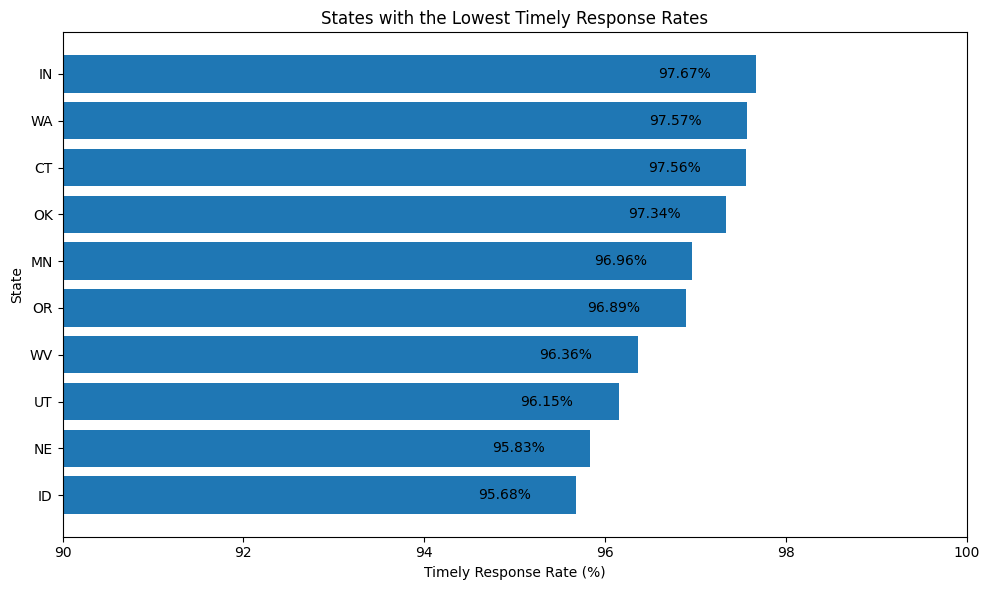

In [36]:
lowest_state_response = (
    timely_response_by_state["Yes"]
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    lowest_state_response.index,
    lowest_state_response.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value - 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

plt.xlim(90, 100)
plt.title("States with the Lowest Timely Response Rates")
plt.xlabel("Timely Response Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Only states with at least 100 complaints are included in the timely-response comparison to reduce instability caused by very small sample sizes.

# **13. Does Timely Response Differ by Complaint Issue?**

In [37]:
issue_analysis = (
    df.groupby("issue")
      .agg(
          complaint_count=("timely_response", "size"),
          timely_rate=(
              "timely_response",
              lambda x: (x == "Yes").mean() * 100
          )
      )
      .sort_values("complaint_count", ascending=False)
)

issue_analysis["timely_rate"] = issue_analysis["timely_rate"].round(2)

print("Issue Analysis")
print("--------------")
print(issue_analysis.head(20))

Issue Analysis
--------------
                                                    complaint_count  \
issue                                                                 
Incorrect information on your report                          37917   
Improper use of your report                                   13369   
Problem with a company's investigation into an ...            12256   
Attempts to collect debt not owed                              4734   
Managing an account                                            2340   
Written notification about debt                                1637   
Took or threatened to take negative or legal ac...             1509   
Problem with a purchase shown on your statement                1492   
False statements or representation                             1131   
Trouble during payment process                                  877   
Problem with a lender or other company charging...              697   
Fraud or scam                                  

In [38]:
issue_analysis_reliable = (
    issue_analysis[issue_analysis["complaint_count"] >= 100]
    .sort_values("timely_rate")
)

print("Issues with Lowest Timely Response Rates")
print("----------------------------------------")
print(issue_analysis_reliable.head(10))

Issues with Lowest Timely Response Rates
----------------------------------------
                                                    complaint_count  \
issue                                                                 
Dealing with your lender or servicer                            598   
Struggling to repay your loan                                   195   
Money was not available when promised                           199   
Unexpected or other fees                                        126   
Getting the loan                                                107   
Closing on a mortgage                                           161   
Charged fees or interest you didn't expect                      250   
Electronic communications                                       182   
Problem with additional add-on products or serv...              107   
Didn't provide services promised                                147   

                                                    timely_rate  

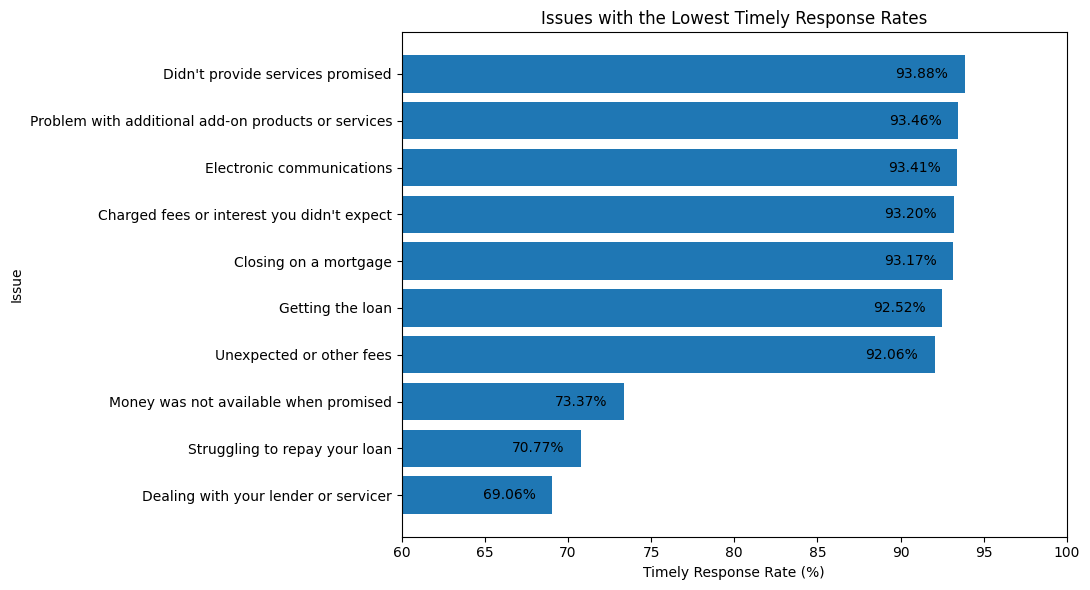

In [39]:
lowest_issue_response = (
    issue_analysis_reliable["timely_rate"]
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    lowest_issue_response.index,
    lowest_issue_response.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value - 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

plt.xlim(60, 100)
plt.title("Issues with the Lowest Timely Response Rates")
plt.xlabel("Timely Response Rate (%)")
plt.ylabel("Issue")
plt.tight_layout()
plt.show()

**Interpretation:** Some complaint issues have considerably lower timely-response rates than others, particularly lender/loan-related issues. This suggests that complaint issue may contain useful predictive signal.

# **14. Does Timely Response Differ by Company?**

In [40]:
company_analysis = (
    df.groupby("company")
      .agg(
          complaint_count=("timely_response", "size"),
          timely_rate=(
              "timely_response",
              lambda x: (x == "Yes").mean() * 100
          )
      )
)

company_analysis["timely_rate"] = (
    company_analysis["timely_rate"].round(2)
)

company_analysis_reliable = (
    company_analysis[
        company_analysis["complaint_count"] >= 100
    ]
    .sort_values("timely_rate")
)

print("Companies with at Least 100 Complaints")
print("---------------------------------------")
print(company_analysis_reliable)

Companies with at Least 100 Complaints
---------------------------------------
                                        complaint_count  timely_rate
company                                                             
MOHELA                                              465        39.35
SYNCHRONY FINANCIAL                                 730        93.42
Shellpoint Partners, LLC                            153        97.39
BANK OF AMERICA, NATIONAL ASSOCIATION              1139        98.16
Block, Inc.                                         713        99.02
LEXISNEXIS                                          354        99.15
GOLDMAN SACHS BANK USA                              168        99.40
CCS Financial Services, Inc.                        221        99.55
Portfolio Recovery Associates, LLC                  539        99.63
Pending Company Match                              3207        99.97
Experian Information Solutions Inc.               21764        99.99
CITIBANK, N.A.          

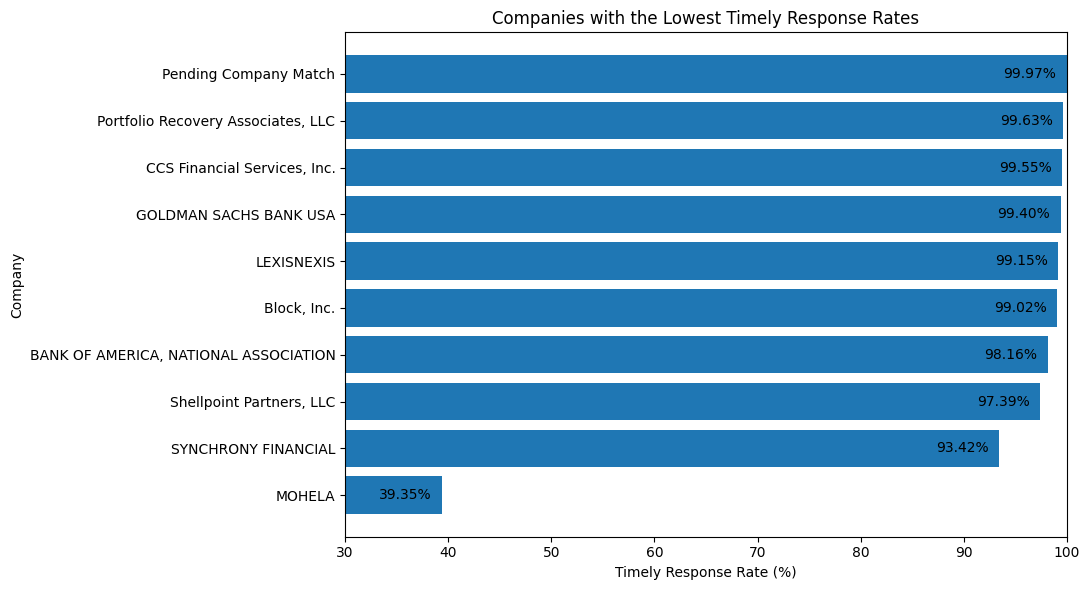

In [41]:
lowest_company_response = (
    company_analysis_reliable["timely_rate"]
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    lowest_company_response.index,
    lowest_company_response.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value - 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

plt.xlim(30, 100)
plt.title("Companies with the Lowest Timely Response Rates")
plt.xlabel("Timely Response Rate (%)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

**Interpretation:** Timely response rates vary substantially across companies. Among companies with at least 100 complaints, MOHELA has a particularly low timely-response rate relative to many other companies, suggesting that company may contain useful predictive signal.

# **15. Does Timely Response Differ by Sub-Product?**

In [42]:
sub_product_analysis = (
    df.groupby("sub_product")
      .agg(
          complaint_count=("timely_response", "size"),
          timely_rate=(
              "timely_response",
              lambda x: (x == "Yes").mean() * 100
          )
      )
)

sub_product_analysis["timely_rate"] = (
    sub_product_analysis["timely_rate"].round(2)
)

sub_product_reliable = (
    sub_product_analysis[
        sub_product_analysis["complaint_count"] >= 100
    ]
    .sort_values("timely_rate")
)

print("Sub-Products with at Least 100 Complaints")
print("-----------------------------------------")
print(sub_product_reliable)

Sub-Products with at Least 100 Complaints
-----------------------------------------
                                            complaint_count  timely_rate
sub_product                                                             
International money transfer                            207        65.70
Federal student loan servicing                          810        65.80
Government benefit card                                 232        88.36
Debt settlement                                         354        92.94
Installment loan                                        705        93.19
Rental debt                                             580        93.62
Payday loan debt                                        161        94.41
Store credit card                                       574        95.30
Lease                                                   214        95.33
Private student loan                                    201        96.02
Auto debt                               

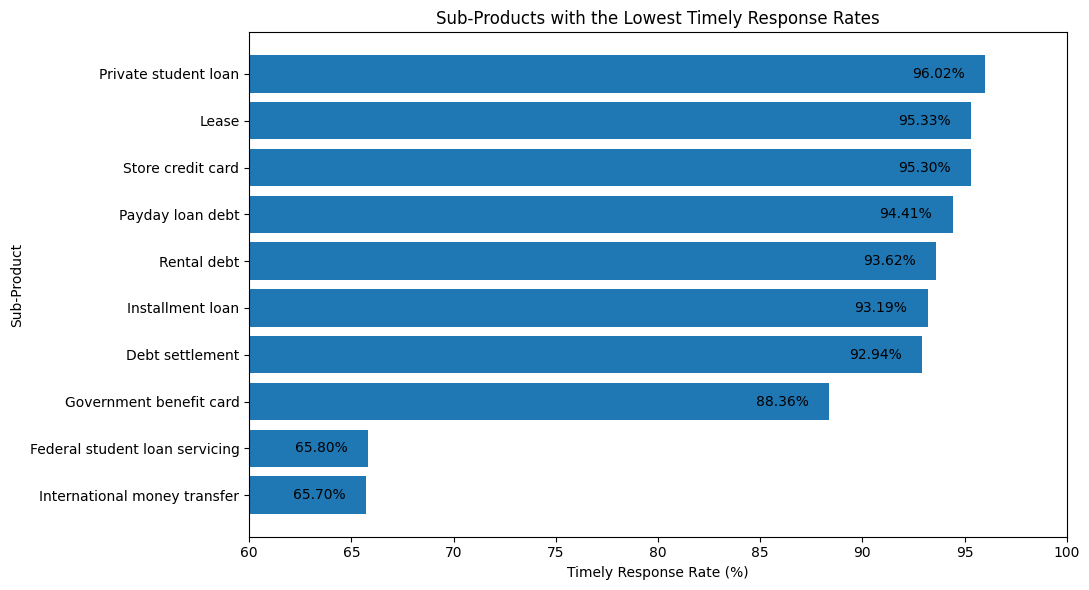

In [43]:
lowest_sub_product_response = (
    sub_product_reliable["timely_rate"]
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    lowest_sub_product_response.index,
    lowest_sub_product_response.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value - 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

plt.xlim(60, 100)
plt.title("Sub-Products with the Lowest Timely Response Rates")
plt.xlabel("Timely Response Rate (%)")
plt.ylabel("Sub-Product")
plt.tight_layout()
plt.show()

**Interpretation:** Timely response rates vary considerably across sub-products. International money transfer and federal student loan servicing have among the lowest rates, while credit reporting has a very high timely-response rate despite having the largest complaint volume.

# **16. Complaint Forwarding Time**

The following derived variable measures the elapsed time between receiving a complaint and sending it to the company.

This is a derived analytical feature created for EDA. It is not a replacement for the original date columns.

In [44]:
df["days_to_company"] = (
    df["date_sent_to_company"] - df["date_received"]
).dt.total_seconds() / (24 * 60 * 60)

print("Response Time Summary")
print("---------------------")
print(df["days_to_company"].describe())

Response Time Summary
---------------------
count    86932.000000
mean         1.235212
std          9.551951
min          0.000012
25%          0.001157
50%          0.002928
75%          0.007384
max        304.206574
Name: days_to_company, dtype: float64


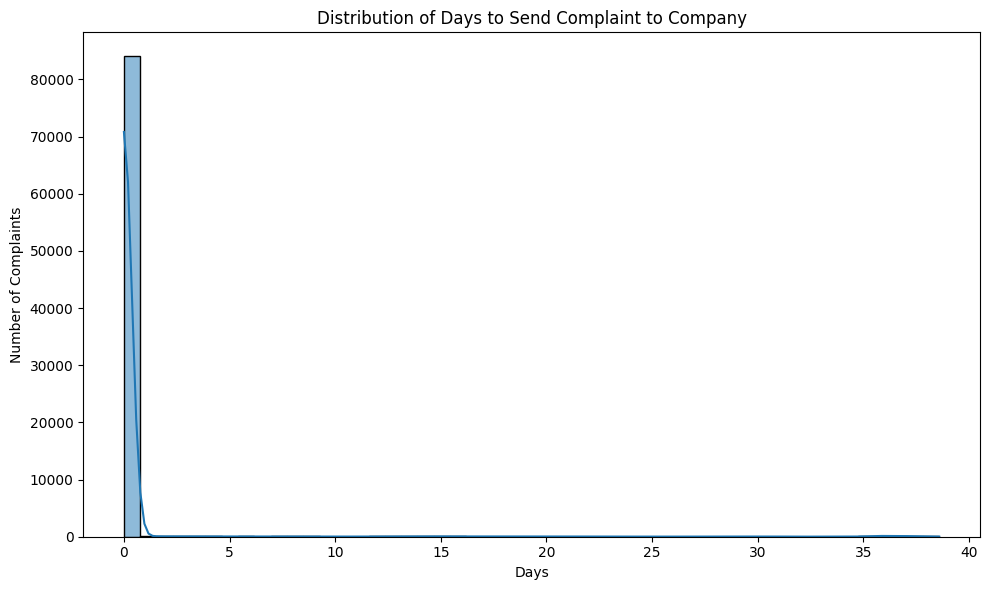

In [45]:
response_time_clean = df["days_to_company"].dropna()

upper_limit = response_time_clean.quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    response_time_clean[response_time_clean <= upper_limit],
    bins=50,
    kde=True
)

plt.title("Distribution of Days to Send Complaint to Company")
plt.xlabel("Days")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

**Visualization note:** The 99th percentile is used only to make the histogram readable by reducing the visual effect of extreme values. Extreme values are not removed from the dataset.

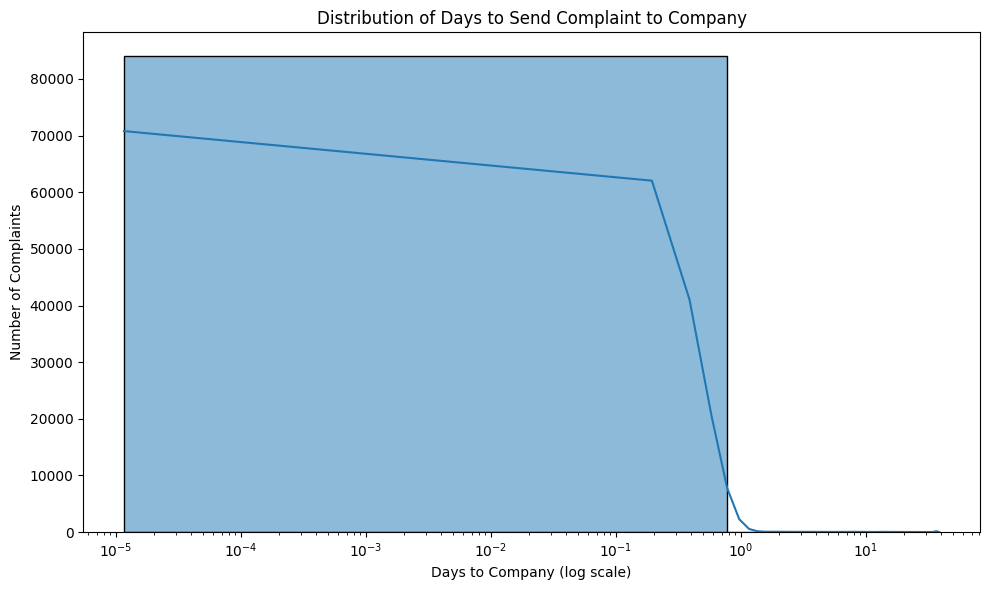

In [46]:
response_time_clean = df["days_to_company"].dropna()

upper_limit = response_time_clean.quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    response_time_clean[response_time_clean <= upper_limit],
    bins=50,
    kde=True
)

plt.xscale("log")

plt.title("Distribution of Days to Send Complaint to Company")
plt.xlabel("Days to Company (log scale)")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

# **17. Does Complaint Forwarding Time Differ by Financial Product?**

Because response time is highly skewed, the median is used to represent a typical complaint. The median is less affected by extreme values than the mean.

In [47]:
response_time_by_product = (
    df.groupby("product")["days_to_company"]
      .median()
      .sort_values()
)

print("Median Days to Send Complaint to Company by Product")
print("---------------------------------------------------")
print(response_time_by_product)

Median Days to Send Complaint to Company by Product
---------------------------------------------------
product
Credit reporting or other personal consumer reports        0.002037
Debt collection                                            0.005428
Debt or credit management                                  0.010035
Checking or savings account                                0.011169
Student loan                                               0.011782
Credit card                                                0.012321
Money transfer, virtual currency, or money service         0.012373
Vehicle loan or lease                                      0.013316
Prepaid card                                               0.013484
Payday loan, title loan, personal loan, or advance loan    0.013727
Mortgage                                                   0.016146
Other                                                           NaN
Name: days_to_company, dtype: float64


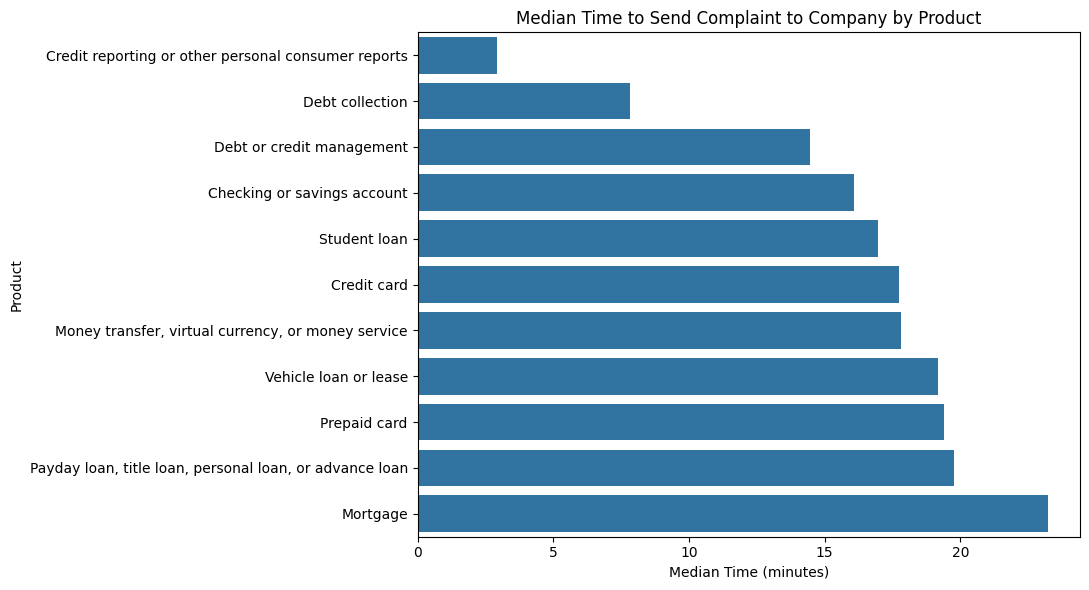

In [48]:
response_time_product = (
    df.groupby("product")["days_to_company"]
      .median()
      .dropna()
      .sort_values()
      .reset_index()
)

response_time_product["median_minutes"] = (
    response_time_product["days_to_company"] * 24 * 60
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=response_time_product,
    x="median_minutes",
    y="product"
)

plt.title("Median Time to Send Complaint to Company by Product")
plt.xlabel("Median Time (minutes)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

**Interpretation:** The median time taken to send complaints to companies varies across financial products, but typical complaints are forwarded within minutes. Credit reporting complaints have the shortest median time, while mortgage complaints have the longest.

# **18. Does Timely Response Differ Based on Complaint Tags?**

In [49]:
tag_counts = df["tags"].value_counts()

print("Complaints by Tag")
print("-----------------")
print(tag_counts)

Complaints by Tag
-----------------
tags
No tag                           85398
Servicemember                     2830
Older American                    1522
Older American, Servicemember      362
Name: count, dtype: int64


In [50]:
tag_timely_rate = (
    pd.crosstab(
        df["tags"],
        df["timely_response"],
        normalize="index"
    ) * 100
).round(2)

print("Timely Response Rate by Tag")
print("---------------------------")
print(tag_timely_rate)

Timely Response Rate by Tag
---------------------------
timely_response                  No    Yes
tags                                      
No tag                         1.11  98.89
Older American                 3.09  96.91
Older American, Servicemember  1.66  98.34
Servicemember                  3.64  96.36


**Interpretation:** Timely response rates vary across complaint tags, with Servicemember and Older American complaints showing lower timely-response rates than complaints with no tag. However, the tag variable is highly imbalanced because most complaints have no tag.

# **19. Does Narrative Availability Differ in Timely Response?**

A derived boolean feature is created to indicate whether a consumer complaint narrative is available.

In [51]:
df["has_narrative"] = (
    df["consumer_complaint_narrative"].notna()
)

narrative_analysis = (
    pd.crosstab(
        df["has_narrative"],
        df["timely_response"],
        normalize="index"
    ) * 100
).round(2)

print("Timely Response Rate by Narrative Availability")
print("-----------------------------------------------")
print(narrative_analysis)

Timely Response Rate by Narrative Availability
-----------------------------------------------
timely_response   No   Yes
has_narrative             
False            0.4  99.6
True             4.1  95.9


**Interpretation:** Complaints with a consumer narrative have a noticeably lower timely-response rate than complaints without a narrative, suggesting that narrative availability may be a useful predictive feature.

# **20. Missing-Value Context for Later Modeling**

Some missing values were intentionally retained during data cleaning. This section summarizes them so that later modeling can make explicit decisions about missing-data handling.

In [52]:
missing_analysis = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_analysis = (
    missing_analysis[
        missing_analysis["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print("Missing Value Analysis")
print("----------------------")
display(missing_analysis)

Missing Value Analysis
----------------------


,missing_count,missing_percentage
consumer_complaint_narrative,70000,77.68
company_public_response,54692,60.69
company_response_to_consumer,15807,17.54
date_sent_to_company,3180,3.53
days_to_company,3180,3.53


# **21. EDA Findings and Modeling Handoff**

## Main findings from this EDA

- Complaint volume is highly concentrated in certain financial products and issues.
- Complaint activity increases sharply in the recent period represented in the dataset; July 2026 is partial-month data.
- `timely_response` is highly imbalanced, which should influence later model evaluation.
- Timely response rates differ across products, issues, companies, sub-products, tags, and some states.
- Complaint issue, company, product, sub-product, tags, submission method, and narrative availability may provide predictive signal.
- `company_response_to_consumer` requires special caution because it may cause target leakage.
- Complaint forwarding time is highly skewed, so the median is more informative than the mean for product-level comparisons.
- Several columns still contain intentional missing values and will require explicit modeling-stage decisions.

## Derived features created in this notebook

- `days_to_company`
- `has_narrative`

## Recommended next step

Proceed to a dedicated modeling-preparation notebook. Before training, that notebook should:

1. Define the prediction target.
2. Remove or exclude leakage-prone variables.
3. Decide how to handle retained missing values.
4. Encode categorical variables.
5. Select useful features.
6. Split the data into training and test sets using an appropriate strategy.
7. Address the strong class imbalance through evaluation metrics and, if appropriate, class weighting or resampling.